In [1]:
import numpy as np
from astropy.io import ascii, fits
from astropy.io.fits import getdata
from astropy.table import Table, Column,join, unique

# check basic info of the fits file

### There are six extensions, 1 & 4 are table extensions, 2,3 & 5,6 are image extensions for spectra and their errors.
There are three major differences between ext2&3 and ext5&6.

(1) We provide two types of spectra with their errors in ext 2&3 and ext5&6: As an IFU survey, some spacially extended AGNs can be spacially resolved with multiple detections in the HETDEX catalog. We do flux weighted friend-of-friend grouping for all AGN detectids with linking length of (delta_r=5 arcsec, delta_redshift = 0.1) to make the unqiue AGN catalog (Extension 1). For each AGN, we pick up the detectid with the strongest emission line flux as detectid_best.

Ext 2 & 3 are the 1-D spectra for the detectid_best from the HETDEX raw detections database.
Ext 5 & 6 are extracted spectra at the flux weighted friend-of-friend center, i.e. (ra,dec) in Extension 1.

(2) Aonther difference between Ext 2 & 3 and Ext 5 & 6 is the number of rows.
Ext 2 & 3 have 15,944 rows, one row for one AGN, arranged in the same order with Extension 1.
Ext 5 & 6 have 17,693 rows. This is because there are some AGNs that have repeat observations (identified by "shotid" in the table of Extension 4). We provide all the spectra for repeated observations in Ext 5 & 6. In the table of Extension 4, each observation has one row. The row number of Ext 5 & 6 are arranged following Extension 4.

Note: All spectra and measurements are without extinction correction.

In [2]:
fname = 'hetdex_agn_hdr4.fits'
hdul = fits.open(fname)
hdul.info()

Filename: hetdex_agn_hdr4.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  basic_info    1 BinTableHDU    265   15940R x 57C   [J, E, E, E, E, J, J, J, 10A, J, J, K, E, E, E, E, E, 38A, K, 20A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, E, 18A, K]   
  2  flux_array_best    1 ImageHDU        11   (1036, 15940)   float32   
  3  error_array_best    1 ImageHDU        11   (1036, 15940)   float32   
  4  repeat_info    1 BinTableHDU     15   17552R x 3C   [J, J, K]   
  5  flux_array_extract    1 ImageHDU        11   (1036, 17552)   float32   
  6  error_array_extract    1 ImageHDU        11   (1036, 17552)   float32   


# Read extension 1 as a table
## extension 1 has the basic information for each unique AGN, one row per AGN.

In [3]:
agn = Table.read( fname, format = 'fits', hdu = 1 )
agn

agnid,ra,dec,z,z_err,zflag,agn_flag,sflag,field,nshot,nmem,detectid_best,ra_best,dec_best,roff,mag_g_wide,mag_g_wide_err,fiberid,shotid,multiframe,throughput,fwhm_virus,fwhm_virus_err,apcor,wobs_elixer,wobs_err_elixer,flux_LyA,snr_LyA,fwhm_LyA,ew_LyA,flux_CIV,snr_CIV,fwhm_CIV,ew_CIV,flux_CIII,snr_CIII,fwhm_CIII,ew_CIII,flux_MgII,snr_MgII,fwhm_MgII,ew_MgII,flux_OVI,snr_OVI,fwhm_OVI,ew_OVI,wave_pipe,flux_pipe,continuum_pipe,linewidth_pipe,sn_pipe,chi2_pipe,chi2fib_pipe,rsep_dr16q,z_dr16q,sdssid_dr16q,sdss_flag
,deg,deg,,,,,,,,,,deg,deg,arcsec,mag,mag,,,,,arcsec,arcsec,,Angstrom,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,Angstrom,1e-17 erg / (s cm2),1e-17 erg / (Angstrom s cm2),Angstrom,,,,arcsec,,,
int32,float32,float32,float32,float32,int32,int32,int32,bytes10,int32,int32,int64,float32,float32,float32,float32,float32,bytes38,int64,bytes20,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float32,bytes18,int64
0,188.15636,52.06209,4.61,0.00074,1,1,3,dex-spring,1,7,4028104326,188.15636,52.062126,0.1248,22.99089,0.018883757,20190408015_3_multi_308_047_024_LU_069,20190408015,multi_308_047_024_LU,0.1888,1.5043367,0.17419368,0.943,5501.84,0.73,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,5501.84,11.1,1.17,4.68,8.85,2.16,1.47,0.43,4.61,123237.49+520343.8,1
1,244.06763,51.560413,4.526,0.00171,1,1,3,dex-spring,1,7,3013694014,244.06757,51.560402,0.1284,23.195978,0.03861265,20210809015_3_multi_422_078_069_RU_097,20210809015,multi_422_078_069_RU,0.159,1.6918566,0.17706198,0.874,5454.74,1.69,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,5454.74,7.97,2.69,2.43,5.47,4.56,0.83,0.65,4.526,161616.26+513336.9,1
2,213.22672,54.23616,4.326,0.00098,1,1,3,dex-spring,1,5,3011328939,213.22679,54.236164,0.1506,22.264854,0.016624752,20210116030_2_multi_307_085_076_LL_108,20210116030,multi_307_085_076_LL,0.161,1.3749195,0.15559101,0.383,5478.63,1.01,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,1024.57,30.957,7346.61,592.59,5478.63,22.59,3.78,4.59,8.27,2.46,1.38,0.7,4.326,141254.37+541410.8,1
3,177.41316,50.566814,4.302,0.00158,1,1,3,dex-spring,1,13,3005373107,177.41318,50.56686,0.1562,21.976244,0.018747311,20191230027_3_multi_017_097_022_RL_093,20191230027,multi_017_097_022_RL,0.1204,2.323946,0.42757708,0.899,5388.8,1.61,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,983.63,33.319,14619.0,1916.87,5388.8,16.43,2.28,4.35,6.2,2.59,0.85,0.19,4.302,114939.14+503400.6,1
4,208.12737,53.18578,4.223,0.00119,1,1,1,dex-spring,1,23,4028846998,208.1273,53.185715,0.2808,21.45631,0.010488038,20230708008_3_multi_510_096_014_LU_109,20230708008,multi_510_096_014_LU,0.1707,2.220662,0.31176051,0.802,4994.14,1.14,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,7.57,2.249,176.08,0.29,4994.14,11.92,4.04,1.87,6.75,4.36,2.53,0.66,4.223,135230.49+531108.6,1
5,203.48918,49.890976,4.18,0.00164,1,1,1,dex-spring,1,19,4025662177,203.48923,49.89098,0.111,21.186956,0.0076022292,20221225025_3_multi_411_014_077_RU_081,20221225025,multi_411_014_077_RU,0.1643,2.340701,0.090775676,0.897,5168.06,1.64,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,1695.46,68.188,5262.83,479.8,5168.06,115.14,2.69,16.23,21.91,2.58,1.22,0.13,4.18,133357.40+495327.6,1
6,210.22366,54.503403,4.17,0.00061,1,1,1,dex-spring,1,21,3012732306,210.2238,54.503437,0.3098,21.75361,0.010511106,202105170

## Check descriptions of each column of the table

In [4]:
agn.info

<Table length=15940>
      name       dtype              unit                                  description                      
--------------- ------- ---------------------------- ------------------------------------------------------
          agnid   int32                                    Artificial sequencial number for each unique AGN
             ra float32                          deg           RA  of the AGN (center of flux weighted FoF)
            dec float32                          deg           DEC of the AGN (center of flux weighted FoF)
              z float32                                                                            Redshift
          z_err float32                                                                   Error of redshift
          zflag   int32                                               zflag=0/1: 1 confirmed z; 0 guessed z
       agn_flag   int32                                      agn_flag=0/1: 1 confirmed AGN; 0 AGN candidate
       

# read extension 2 in as a 2-d array

In [5]:
from astrowidgets import ImageWidget

#hdu2, hdr2 = getdata( fname, 2, header = True )
print(hdul[2].header)
im    = hdul[2].data # read spectra in from extension 2
im_er = hdul[3].data # read errors  in from extension 3 if needed

imw = ImageWidget()
#imw.cuts = (-1, 20)
imw.load_array(im)
display(imw)

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1036                                                  NAXIS2  =                15940                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'flux_array_best'                                                     HIERARCH wave_start = '3470.0 AA'                                               HIERARCH wave_step = '   2.0 AA'                                                HIERARCH flux_unit = '1.0e-17 * erg / (cm^2 * s * AA)'                          END                                                                                                                     

ImageWidget(children=(Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\x…

## The information of the wave_array corresponds to the flux_array in each row can be found in the header:
### wave_start = 3470.0, wave_step = 2.0

In [6]:
hdul[2].header['wave_start'], hdul[2].header['wave_step'], hdul[2].header['flux_unit']

('3470.0 AA', '   2.0 AA', '1.0e-17 * erg / (cm^2 * s * AA)')

In [7]:
# prepare wavelength array for the spectra
wave_start = 3470.0
wave_step  = 2.0
n_elements = hdul[2].header['NAXIS1'] #1036
wave_arr = wave_start + wave_step * np.arange( 0, n_elements )
wave_arr

array([3470., 3472., 3474., ..., 5536., 5538., 5540.])

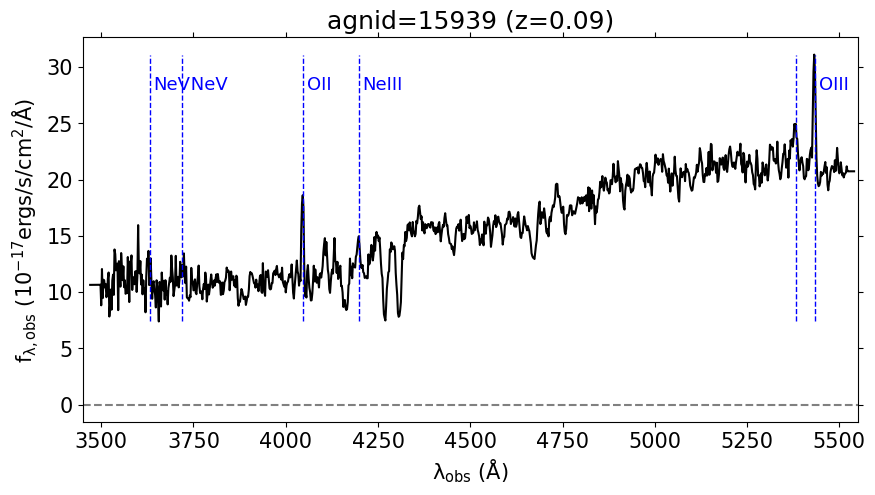

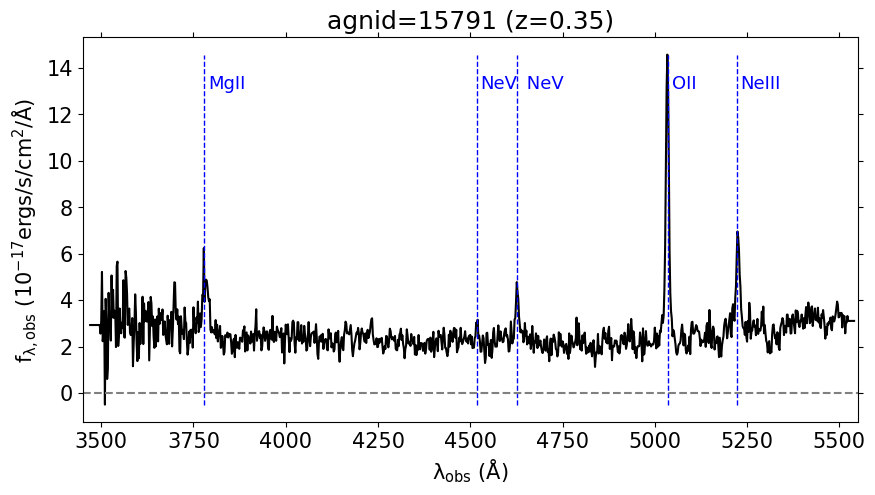

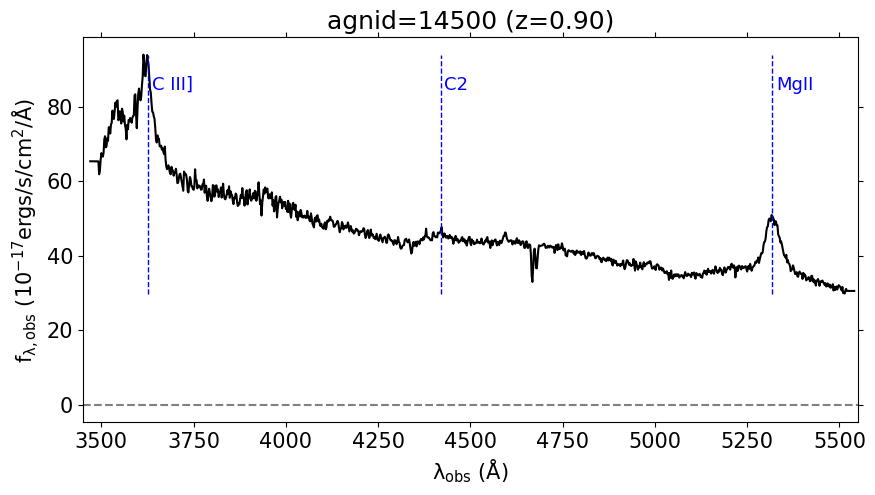

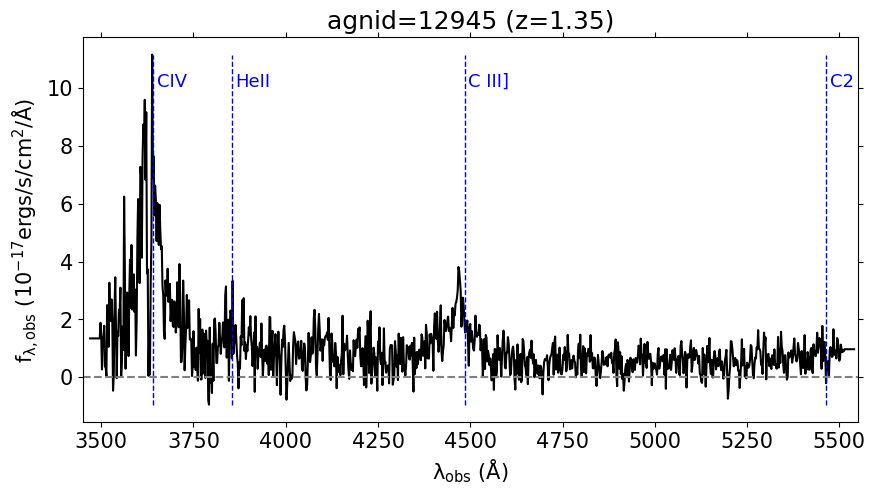

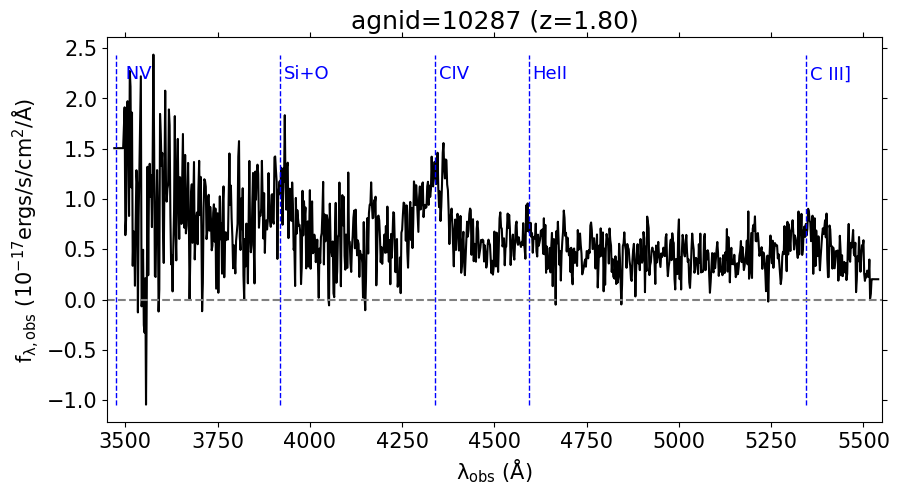

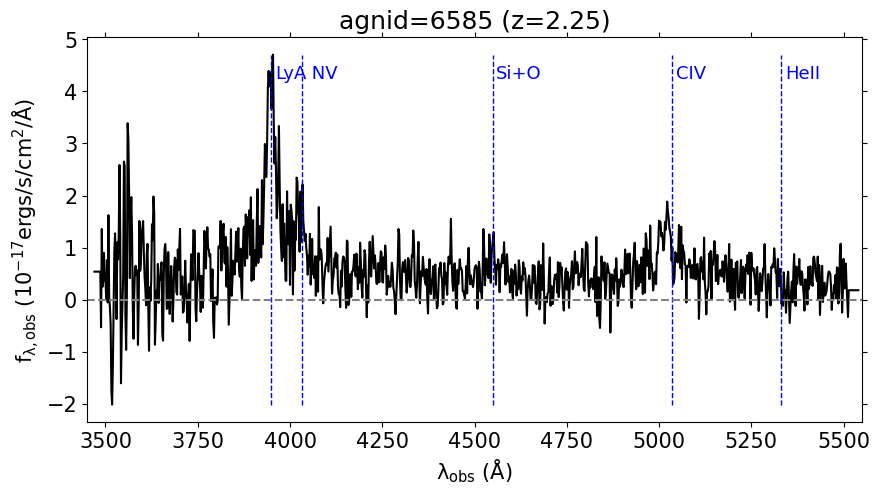

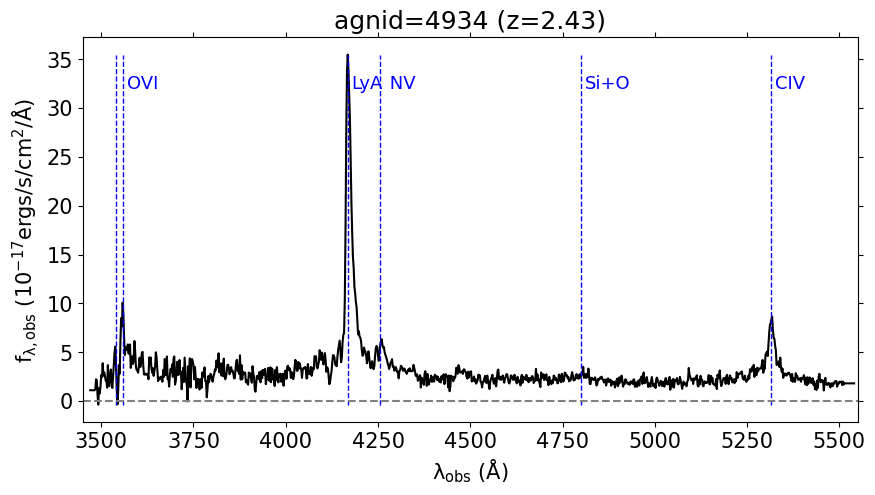

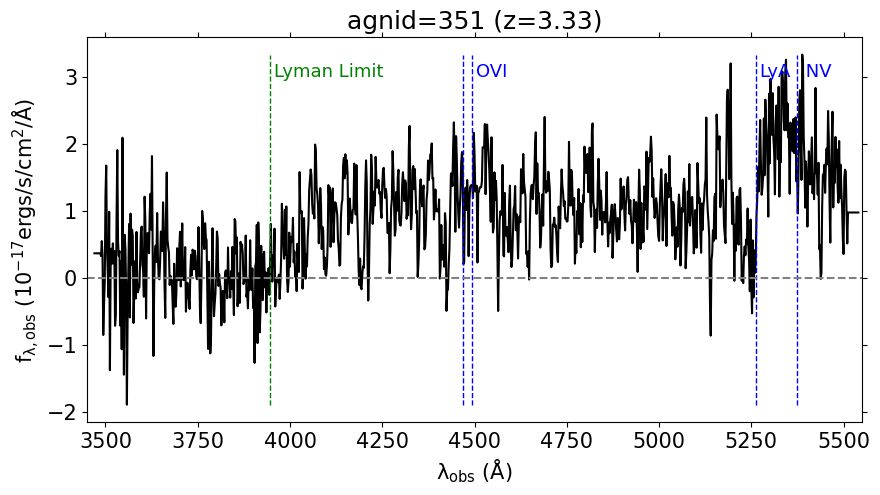

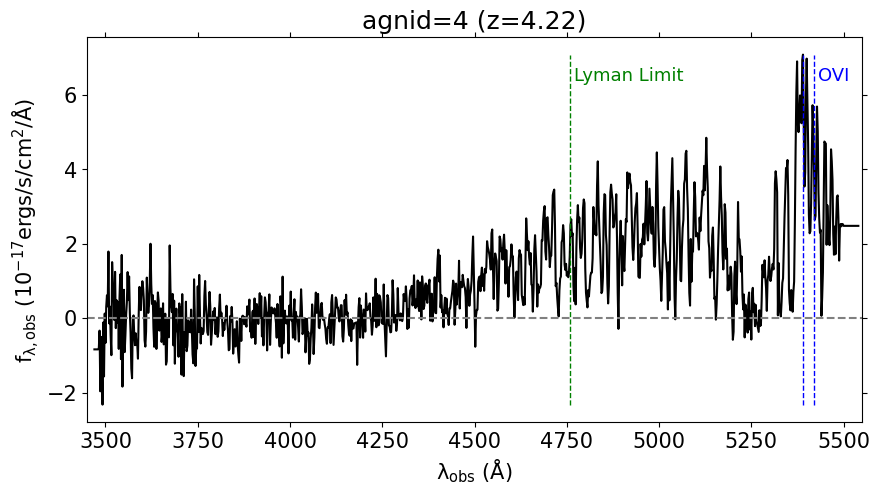

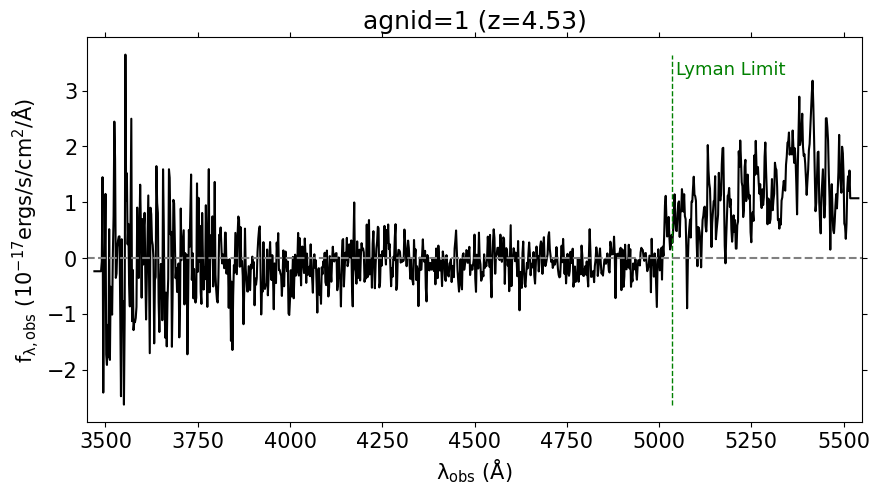

In [8]:
from IPython.display import Image
import matplotlib.pyplot as plt

# ............
w_LyL   = 911.3 
w_CIIIa = 977.030
w_NIII  = 991.514
w_OVIa  = 1031.912
w_OVIb  = 1037.613
w_LyA   = 1215.24 
w_NV    = 1240.81
w_OI    = 1305.53
w_CIIa  = 1335.31
w_SiO   = 1399.8
w_CIV   = 1549.48
w_HeII  = 1640.40
w_OIII  = 1665.85
w_CIIIb = 1908.734
w_CIIb  = 2326.0
w_NeIV  = 2439.5
w_MgII  = 2799.117
w_OII   = 3729.875
w_NeVa  = 3346.79
w_NeV   = 3426.85
w_NeIII = 3868.760
w_hd    = 4102.89
w_hg    = 4341.68
w_OIII = 5008.240
# ............

fontsize = 15
xl, xh = 3450, 5550 

# plot some example spectra at the following redshifts
z_sel = np.array( [ 0.1,0.35, 0.9, 1.35, 1.8, 2.25, 2.43, 3.33, 4.3, 4.6 ] )

for i in range(np.size(z_sel)):
    sel  = agn['z'] < z_sel[i]
    dtmp = im[sel]
    flux_arr = dtmp[0]
    
    fig, ax = plt.subplots( figsize = ( 10., 5.)  )
    
    plt.plot( wave_arr, flux_arr, 'k' )
    
    lines   = np.array( [  w_LyL, w_OVIa, w_OVIb, w_LyA,   w_NV,   w_SiO,  w_CIV, w_HeII,   w_CIIb, w_CIIIb,  w_MgII,4960, w_OII, w_NeVa, w_NeV, w_NeIII, w_OIII  ] )
    labels  = np.array( [  'Lyman Limit',' ',     'OVI',  'LyA',' NV', 'Si+O',   'CIV', 'HeII',    'C2', 'C III]', 'MgII', '','OII', 'NeV',' NeV', 'NeIII','OIII' ] )    

    yl, yh = np.min(flux_arr), np.max(flux_arr)
    for i in range( np.size(lines) ):
        wline = lines[i] * ( 1 + agn[sel]['z'][0] )
        color = 'blue'
        if( ( wline >= xl ) and (wline <= xh ) ):
            if(labels[i] == 'Lyman Limit'):
                color = 'green'
            wline = np.full( 2, wline )     
            plt.text( wline[0]+10, 0.9 * yh, labels[i], color = color, fontsize=13 )
            plt.plot( wline,  np.array([yl,yh]), color = color, linestyle = '--', linewidth = 1.0 )
    
    plt.xlim( xl, xh )
    plt.tick_params( which = 'both', bottom=True, top=True, left=True, right=True )
    plt.axhline(0,color = 'gray', ls = '--')
    #plt.grid()
    
    plt.xlabel('$\\mathrm{\\lambda_{obs}\\ (\\AA)}$',fontsize=fontsize)
    plt.ylabel('$\\mathrm{f_{\\lambda,obs}\\ (10^{-17} ergs/s/cm^2/\\AA)}$',fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    #stitle = 'agnid=%d, detectid_best=%d, z=%.2f (zflag=%d)' \
    #         % (agn[sel]['agnid'][0], agn[sel]['detectid_best'][0], agn[sel]['z'][0],agn[sel]['zflag'][0])
    stitle = 'agnid=%d (z=%.2f)' \
             % (agn[sel]['agnid'][0], agn[sel]['z'][0])
    plt.title( stitle, fontsize=1.2*fontsize )
    plt.show()
    #plt.savefig( 'tmp.png', format='png')
    #Image('tmp.png')

# Read extension 4 in as a table of repeat observation info
### There are some repeat observations for some agns. In this table, each observation has one entry with a unique "shotid", nshots shows the number of repeat observations for each unique AGN.

In [9]:
tab = Table.read( fname, format = 'fits', hdu = 4 )
tab

agnid,nshot,shotid
int32,int32,int64
0,1,20220602007
1,1,20210809015
2,1,20210116030
3,1,20191230027
4,1,20230708008
5,1,20221225025
6,1,20210517021
7,1,20191006024
8,1,20190504027


In [10]:
key = 'nshot'
sel = tab[key] == 1
n1 = np.sum(sel)
print("There are %5d AGNs that are only observed once" % n1)

sel = tab[key] == 2
dtmp = np.unique( tab[sel]['agnid'] )
n2 = np.size(dtmp)
print("There are %5d AGNs that are observed twice" % n2 )

sel = tab[key] > 2
dtmp = np.unique( tab[sel]['agnid'] )
n3 = np.size(dtmp)
print("There are %5d AGNs that are observed more than twice" % n3 )
print("Note:")
print('%5d AGNs can be successfully extracted with spectra at their fof grouping center (ra,dec) in Extension 1.' \
      % (n1+n2+n3) )
print('%5d AGNs are lack of their extracted spectra because of their flux weighted fof center falling on bad amplifiers.'\
      % (np.size(agn)-(n1+n2+n3)))

There are 14306 AGNs that are only observed once
There are  1125 AGNs that are observed twice
There are   240 AGNs that are observed more than twice
Note:
15671 AGNs can be successfully extracted with spectra at their fof grouping center (ra,dec) in Extension 1.
  269 AGNs are lack of their extracted spectra because of their flux weighted fof center falling on bad amplifiers.


# Find all spectra and their error of a certain AGN in Extension 5 and 6
### Find some strong agns (big nmem) with secure redshifts (zflag=1) with more than five repeat observations

In [11]:
sel1 = agn['nshot'] >= 5
sel2 = agn['zflag'] == 1
sel  = sel1 * sel2
dtmp = agn[sel]
sel = np.argsort(-dtmp['nmem'])
dtmp[sel]

agnid,ra,dec,z,z_err,zflag,agn_flag,sflag,field,nshot,nmem,detectid_best,ra_best,dec_best,roff,mag_g_wide,mag_g_wide_err,fiberid,shotid,multiframe,throughput,fwhm_virus,fwhm_virus_err,apcor,wobs_elixer,wobs_err_elixer,flux_LyA,snr_LyA,fwhm_LyA,ew_LyA,flux_CIV,snr_CIV,fwhm_CIV,ew_CIV,flux_CIII,snr_CIII,fwhm_CIII,ew_CIII,flux_MgII,snr_MgII,fwhm_MgII,ew_MgII,flux_OVI,snr_OVI,fwhm_OVI,ew_OVI,wave_pipe,flux_pipe,continuum_pipe,linewidth_pipe,sn_pipe,chi2_pipe,chi2fib_pipe,rsep_dr16q,z_dr16q,sdssid_dr16q,sdss_flag
,deg,deg,,,,,,,,,,deg,deg,arcsec,mag,mag,,,,,arcsec,arcsec,,Angstrom,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,1e-17 erg / (s cm2),,km / s,Angstrom,Angstrom,1e-17 erg / (s cm2),1e-17 erg / (Angstrom s cm2),Angstrom,,,,arcsec,,,
int32,float32,float32,float32,float32,int32,int32,int32,bytes10,int32,int32,int64,float32,float32,float32,float32,float32,bytes38,int64,bytes20,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float32,bytes18,int64
9558,150.23181,2.3639977,1.93,0.00059,1,1,2,cosmos,7,56,3001793203,150.23181,2.364005,0.0377,20.590452,0.004891305,20181120012_2_multi_302_036_041_RL_082,20181120012,multi_302_036_041_RL,0.1567,1.8817229,0.3503828,0.918,4537.33,0.92,774.51,35.926,2689.39,59.39,331.45,25.693,3798.83,43.6,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,4537.33,87.96,8.28,15.76,10.25,1.35,1.18,999.0,-999.0,?,0
12862,334.40262,0.1681359,1.36337,0.00073,1,1,2,ssa22,11,37,3090040799,334.40262,0.16815,0.0533,21.961563,0.016696831,20181012013_1_multi_204_077_037_RU_001,20181012013,multi_204_077_037_RU,0.1394,1.4803985,0.26228106,-99.0,3664.2214,1.1329379,-99.0,-99.0,-99.0,-99.0,337.71,24.623,3102.37,199.13,153.88,14.1,4657.96,116.9,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,1.3662316,221736.64+001005.3,1
12657,150.23077,2.578101,1.404,0.00105,1,1,2,cosmos,6,35,3012150413,150.23077,2.578111,0.0415,19.983688,0.0033815193,20210404010_3_multi_204_087_037_LL_025,20210404010,multi_204_087_037_LL,0.145,2.0509365,0.5071115,0.905,3714.03,1.62,-99.0,-99.0,-99.0,-99.0,728.74,36.898,6872.58,46.6,339.37,18.659,7677.42,30.55,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,3714.03,121.45,20.85,9.32,12.43,2.84,1.2,999.0,-999.0,?,0
3540,215.03596,53.001137,2.588,0.00164,1,1,2,egs,5,22,3000259391,215.03595,53.001137,0.0234,22.052187,0.020210763,20170629004_1_multi_037_073_031_LU_076,20170629004,multi_037_073_031_LU,0.1218,1.5476882,0.43942416,0.931,4343.32,1.99,33.73,6.556,1215.38,9.19,11.4,-999.0,30.58,6.71,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,0.0,0.0,0.0,0.0,4343.32,104.06,0.66,19.13,15.2,1.39,0.52,0.13,2.588,142008.61+530004.0,1
4442,150.3165,2.2467368,2.483,0.0005,1,1,2,cosmos,6,20,4018700932,150.31653,2.246699,0.1764,21.94187,0.016129095,20220309017_3_multi_507_093_054_LU_077,20220309017,multi_507_093_054_LU,0.1668,2.2181032,0.09389865,0.881,3760.55,0.54,133.35,18.573,6496.41,54.21,85.16,14.195,2787.28,45.72,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,26.38,2.666,2987.14,8.89,3760.55,12.6,1.34,2.01,4.56,0.99,1.47,0.18,2.483,100115.96+021448.4,1
13823,334.4101,0.2018004,1.1211,0.00048,1,1,0,ssa22,7,17,4023496911,334.4101,0.201798,0.0279,20.62811,0.006836175,20220805012_1_multi_421_069_006_RL_030,20220805012,multi_421_069_006_RL,0.1074,1.427082,0.18444958,0.949,4050.22,0.91,-99.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,196.52,13.315,1320.09,41.17,-198.0,-99.0,-99.0,-99.0,-198.0,-99.0,-99.0,-99.0,4050.22,38.24,6.08,5.72,8.95,1.12,2.0,999.0,-999.0,?,0
14753,272.12546,65.06346,0.82499,0.00058,1,1,2,nep,7,15,3090086052,272.12534,65.06345,0.2086,19.287,0.0016961425,20190606025_1_multi_008_093_054_RU_013,20190606

### take agnid = 9558 as an example

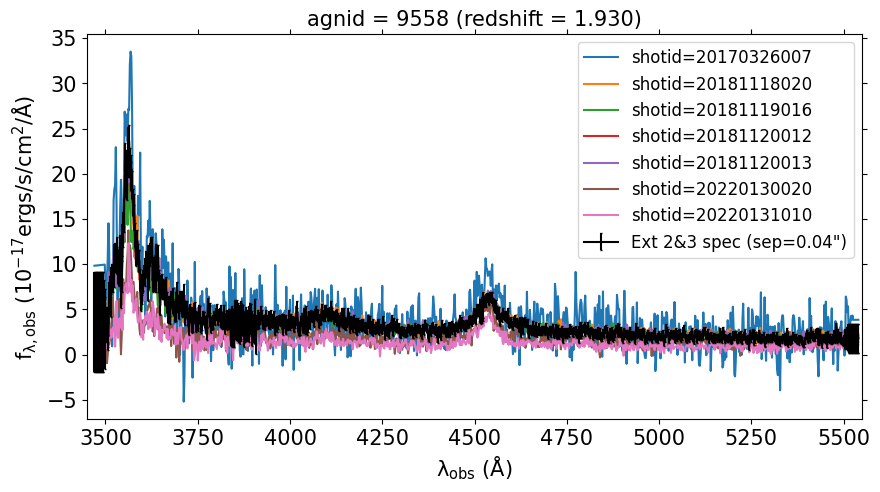

In [12]:
agnid = 9558

im_arr    = hdul[5].data
im_er_arr = hdul[6].data

sel = np.where( tab['agnid'] == agnid )
shotid_arr  = tab[sel]['shotid']
flux_arr    = im_arr[sel]
flux_er_arr = im_er_arr[sel]

# arrange the repeat observations by time
sel = np.argsort( shotid_arr )
shotid_arr, flux_arr, flux_er_arr = shotid_arr[sel], flux_arr[sel], flux_er_arr[sel]

# prepare the wavelength array for the spectra
wave_start = 3470.0
wave_step  = 2.0
n_elements = hdul[5].header['NAXIS1'] #1036
wave_arr = wave_start + wave_step * np.arange( 0, n_elements )

# plot all repeat observations
fig, ax = plt.subplots( figsize = ( 10., 5.)  )

for i in range(np.size(shotid_arr)):
    plt.plot( wave_arr, flux_arr[i], label = 'shotid=%d' % shotid_arr[i])
    #plt.errorbar( wave_arr, flux_arr[i], flux_er_arr[i] , capsize = 1.5, label = '%d' % shotid_arr[i] )

# overplot with the catalog spectrum for detectid_best in ext 2&3 as black and compare with ext 5&6
im_arr    = hdul[2].data
im_er_arr = hdul[3].data
sel = agn['agnid'] == agnid
flux_arr    = im_arr[sel][0]
flux_er_arr = im_er_arr[sel][0]
plt.errorbar( wave_arr, flux_arr, flux_er_arr, color = 'k',capsize = 1., \
              label = 'Ext 2&3 spec (sep=%.2f\")' % agn['roff'][agn['agnid'] == agnid][0])
    
plt.xlim( xl, xh )
plt.tick_params( which = 'both', bottom=True, top=True, left=True, right=True )

plt.xlabel('$\\mathrm{\\lambda_{obs}\\ (\\AA)}$',fontsize=fontsize)
plt.ylabel('$\\mathrm{f_{\\lambda,obs}\\ (10^{-17} ergs/s/cm^2/\\AA)}$',fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.legend(fontsize=fontsize * 0.8)
stitle = 'agnid = %d (redshift = %.3f)' % (agnid,agn['z'][agn['agnid'] == agnid][0])
plt.title( stitle, fontsize=fontsize )
plt.show()